<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [429]:
#Importation de la librairie Pandas
import pandas as pd

In [430]:
#Importation de la librairie plotly express
import plotly.express as px

In [431]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

# df.shape[1]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [432]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

C:\Users\artal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

C:\Users\artal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed

C:\Users\artal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [433]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [434]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.dtypes
for col in df_erp.columns:
    print(f"La colonne {col} comporte {df_erp[col].nunique()} valeur(s)")


La colonne product_id comporte 825 valeur(s)
La colonne onsale_web comporte 2 valeur(s)
La colonne price comporte 383 valeur(s)
La colonne stock_quantity comporte 84 valeur(s)
La colonne stock_status comporte 2 valeur(s)
La colonne purchase_price comporte 660 valeur(s)


In [435]:
#Afficher les 5 premières lignes de la table
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [436]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
any(df_erp.duplicated())

False

In [437]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
# lié à stock_quantity
df_erp['stock_status'].unique()

array(['instock', 'outofstock'], dtype=object)

In [438]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if x<=0 else 'instock')

In [439]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [440]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
sum(df_erp["stock_status"] == df_erp["stock_status_2"])

823

In [441]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [442]:
#Corriger la ou les données incohérentes
df_erp['stock_status'] = df_erp['stock_status_2']
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
sum(df_erp["stock_status"] == df_erp["stock_status_2"])

825

In [443]:
df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,instock,23.77,instock
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,instock
821,7204,0,45.0,9,instock,24.18,instock
822,7247,1,54.8,6,instock,27.18,instock
823,7329,0,26.5,14,instock,13.42,instock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [444]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
print(f"Prix non renseignés ? {any(df_erp['price'].isnull())}")
print(f"Prix négatifs ? {any(df_erp['price']<0)}")
print(f"Prix nuls ? {any(df_erp['price']==0)}")
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(sum(df_erp['price'].isnull()))) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print(f"Prix minimum de la colonne \"price\": {df_erp['price'].min()}")
#Afficher le prix maximum de la colonne "price"
print(f"Prix maximum de la colonne \"price\": {df_erp['price'].max()}")
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print(f"Prix inférieur(s) à 0 : {df_erp[df_erp['price']<0]['price'].tolist()}")

Prix non renseignés ? False
Prix négatifs ? True
Prix nuls ? False
Nombres d'articles avec un prix non renseigné: 0
Prix minimum de la colonne "price": -20.0
Prix maximum de la colonne "price": 225.0
Prix inférieur(s) à 0 : [-20.0, -8.0, -9.1]


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [445]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print(f"Quantité minimum de la colonne \"stock_quantity\": {df_erp['stock_quantity'].min()}")
#Afficher la quantité maximum de la colonne "stock_quantity"
print(f"Quantité maximum de la colonne \"stock_quantity\": {df_erp['stock_quantity'].max()}")
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print(f"Stock(s) inférieur(s) à 0 : {df_erp[df_erp['stock_quantity']<0]['stock_quantity'].tolist()}")
# Il faut les acheter

Quantité minimum de la colonne "stock_quantity": -10
Quantité maximum de la colonne "stock_quantity": 145
Stock(s) inférieur(s) à 0 : [-10, -1]


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [446]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].unique()
# Booléen pour dire si un produit est en vente sur le web

array([1, 0])

In [447]:
#Quelles sont les colonnes à conserver selon vous?
# Toutes sauf stock_status_2

In [448]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp = df_erp.drop('stock_status_2',axis=1)
df_erp.head()


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


In [449]:
df_erp_prix_negatif = df_erp[df_erp['price']<0]
df_erp_prix_negatif
# les enlever du df

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
151,4233,0,-20.0,0,outofstock,10.33
469,5017,0,-8.0,0,outofstock,4.34
739,6594,0,-9.1,19,instock,4.61


In [450]:
df_erp = df_erp[df_erp['price']>=0]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [451]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print(f"Prix non renseigné(s): {df_erp[df_erp['purchase_price'].isnull()]['purchase_price'].tolist()}")
#Afficher le prix minimum de la colonne "purchase_price"
print(f"Prix minimum de la colonne \"purchase_price\": {df_erp['purchase_price'].min()}")
#Afficher le prix maximum de la colonne "purchase_price"
print(f"Prix maximum de la colonne \"purchase_price\": {df_erp['purchase_price'].max()}")

Prix non renseigné(s): []
Prix minimum de la colonne "purchase_price": 2.74
Prix maximum de la colonne "purchase_price": 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [452]:
#Dimension du dataset
#Nombre d'observations
#Nombre de caractéristiques
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))


Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [453]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
print(df_web.dtypes)
for col in df_web.columns:
    print(f"La colonne {col} comporte {df_web[col].nunique()} valeur(s)")

sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64
post_parent                     float64
guid                             object


In [454]:
#Selon vous, quelles sont les colonnes à conserver ?
#sku, total_sales, post_date_gmt, product_type, post_title

In [455]:
df_web = df_web[df_web['post_type']=='product']

In [456]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web[['sku', 'total_sales','post_date_gmt','product_type', 'post_title']]

In [457]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
# [nan, '13127-1', 'bon-cadeau-25-euros']
print(df_web['sku'].unique())
df_web[pd.to_numeric(df_web['sku'], errors='coerce').notna()==False]['sku'].unique()

[14692 15328 16515 16585 12869 15575 14338 16560 15361 15022 16342 16029
 13754 14680 9636 13849 15481 15448 15441 804 16071 12882 16053 13766
 12640 15476 16038 14864 16044 15324 15413 13809 15895 15849 12315 15934
 15148 15781 15106 15490 14507 16307 13736 16037 12587 16305 16131 13435
 15758 14509 14768 16505 15871 11602 13127 13520 13032 15436 15910 16263
 15138 16580 13905 13557 14975 15341 15415 16065 15479 16151 15127 15140
 15779 9937 15281 15315 15668 15161 15792 15921 15870 15690 15561 15539
 16320 3509 2534 11586 14819 15705 15254 15554 14451 16274 14696 14573
 16238 15834 15141 15038 15238 16586 15664 14527 15707 15269 14845 14700
 15440 15759 11277 15676 15731 16525 15785 14699 15718 14372 15881 15426
 16023 14661 15675 15351 12791 13958 '13127-1' 11849 15461 15577 12639
 15466 15184 13904 15793 15612 15425 14599 15033 16449 15829 13965 16306
 15303 13996 14679 15318 13599 15206 16153 16067 15241 16264 14915 16289
 15229 15713 15654 15879 12586 15710 15204 16462 14596 1529

array(['13127-1', nan, 'bon-cadeau-25-euros'], dtype=object)

In [458]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
df_web[pd.to_numeric(df_web['sku'], errors='coerce').notna()==False]['sku'].unique()

array(['13127-1', nan, 'bon-cadeau-25-euros'], dtype=object)

In [459]:
#Identifier les lignes sans code article
df_web[df_web['sku'].isna()]

,sku,total_sales,post_date_gmt,product_type,post_title
1084,NaN,-56.0,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018
1087,NaN,-17.0,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017


In [460]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
df_web[df_web['sku'].isin(['13127-1', 'bon-cadeau-25-euros'])]
# bon-cadeau-25-euros : à garder selon ce qu'on voudra analyser
# 13127-1 : à remplacer par 13127

,sku,total_sales,post_date_gmt,product_type,post_title
272,13127-1,4.0,2020-06-09 13:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007
1387,bon-cadeau-25-euros,7.0,2018-06-01 11:53:46,NaN,Bon cadeau de 25€


In [461]:
df_web.loc[df_web['sku']=='13127-1','sku']=13127

In [462]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
any(df_web.duplicated())

False

In [463]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_web_no_sku = df_web[df_web['sku'].isna()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_web_no_sku.info()
#3 - Que constatez-vous?
# il y a quand même des valeurs dans d'autres colonnes
# deux ventes de vin, Pierre Jean Villa Condrieu Jardin Suspendu 2018 et Pierre Jean Villa Côte Rôtie Fongeant 2017 à -56 et -17

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 1084 to 1087
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sku            0 non-null      object        
 1   total_sales    2 non-null      float64       
 2   post_date_gmt  2 non-null      datetime64[ns]
 3   product_type   2 non-null      object        
 4   post_title     2 non-null      object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 96.0+ bytes


In [464]:
df_web_no_sku['total_sales'].unique()

array([-56., -17.])

In [465]:
# verif si lignes avec vente faite mais on retrouve pas le produit

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [466]:
#Dimension du dataset
#Nombre d'observations
#Nombre de caractéristiques
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [467]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
print(df_liaison.dtypes)
for col in df_liaison.columns:
    print(f"La colonne {col} comporte {df_liaison[col].nunique()} valeur(s)")

id_web        object
product_id     int64
dtype: object
La colonne id_web comporte 734 valeur(s)
La colonne product_id comporte 825 valeur(s)


In [468]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
df_liaison['product_id'].nunique() == len(df_liaison['product_id'])

True

In [469]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
df_liaison['id_web'].nunique() == len(df_liaison['id_web'])

False

In [470]:
#Avons-nous des articles sans correspondance?
df_liaison[df_liaison['id_web'].isna()]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


In [471]:
df_liaison = df_liaison[df_liaison['id_web'].notna()]

In [472]:
df_liaison.loc[df_liaison['id_web']=='13127-1','id_web']=13127

In [473]:
df_liaison

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039
...,...,...
792,15891,7023
793,15887,7025
822,13127,7247
823,14680-1,7329


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [474]:
#Fusion des fichiers df_erp et df_liaison
df_erp_liaison = df_erp.merge(df_liaison,on='product_id',how='left')

In [475]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
# 91 lignes
print(df_erp_liaison[df_erp_liaison['id_web'].isna()])
print(df_erp_liaison[(df_erp_liaison['id_web'].isna())&(df_erp_liaison['onsale_web']==1)])
df_erp_liaison = df_erp_liaison[df_erp_liaison['id_web'].notna()]

     product_id  onsale_web  price  stock_quantity stock_status  \
19         4055           0   86.1               0   outofstock   
49         4090           0   73.0               0   outofstock   
50         4092           0   47.0               0   outofstock   
119        4195           0   14.1               0   outofstock   
131        4209           0   73.5               0   outofstock   
..          ...         ...    ...             ...          ...   
814        7196           0   31.0              55      instock   
815        7200           0   31.0               6      instock   
816        7201           0   31.0              18      instock   
817        7203           0   45.0              30      instock   
818        7204           0   45.0               9      instock   

     purchase_price id_web  
19            37.88    NaN  
49            33.79    NaN  
50            25.25    NaN  
119            7.36    NaN  
131           33.01    NaN  
..              ...  

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [476]:
#Fusionner les datasets df_merge et df_web
df_merge = df_erp_liaison.merge(df_web,left_on='id_web',right_on='sku',how='outer',indicator=True)

In [477]:
df_merge[df_merge['_merge']=="right_only"]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_date_gmt,product_type,post_title,_merge
736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-56.0,2018-08-08 09:23:43,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,right_only
737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-17.0,2018-07-31 10:07:23,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,right_only


In [478]:
#Avons-nous des lignes sans correspondance?
df_merge[df_merge['sku'].isna()]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_date_gmt,product_type,post_title,_merge
81,4741.0,0.0,12.4,0.0,outofstock,6.66,12601,NaN,NaN,NaT,NaN,NaN,left_only
130,5957.0,0.0,39.0,0.0,outofstock,20.75,13577,NaN,NaN,NaT,NaN,NaN,left_only
142,4289.0,0.0,22.8,0.0,outofstock,11.90,13771,NaN,NaN,NaT,NaN,NaN,left_only
183,4869.0,0.0,17.2,0.0,outofstock,9.33,14360,NaN,NaN,NaT,NaN,NaN,left_only
188,5955.0,0.0,27.3,0.0,outofstock,13.68,14377,NaN,NaN,NaT,NaN,NaN,left_only
189,5953.0,0.0,47.5,0.0,outofstock,23.81,14379,NaN,NaN,NaT,NaN,NaN,left_only
215,5505.0,0.0,10.1,0.0,outofstock,5.22,14648,NaN,NaN,NaT,NaN,NaN,left_only
221,5800.0,0.0,32.3,0.0,outofstock,16.02,14689,NaN,NaN,NaT,NaN,NaN,left_only
227,5559.0,0.0,27.9,3.0,instock,13.98,14715,NaN,NaN,NaT,NaN,NaN,left_only
230,5570.0,0.0,22.5,0.0,outofstock,11.16,14730,NaN,NaN,NaT,NaN,NaN,left_only


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: title={'center': 'Répartition des prix'}>

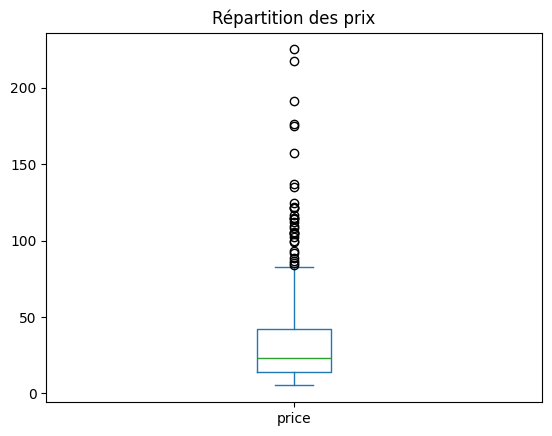

In [480]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge['price'].plot.box(title="Répartition des prix")

In [481]:
#Autre méthode avec plotly express
px.box(df_merge, y='price', title="Répartition des prix")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [482]:
#Calculer la moyenne du prix
moy = df_merge['price'].mean()
print(f"Moyenne : {moy}")
#Calculer l'écart-type du prix
std = df_merge['price'].std()
print(f"Écart type : {std}")
#Calculer le Z-score
df_merge['z_score']=(df_merge['price']-moy)/std

Moyenne : 32.10930706521739
Écart type : 27.292786636331787


In [483]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
# 114
df_merge[df_merge['z_score']>=3].sort_values(by='z_score').head(1)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_date_gmt,product_type,post_title,_merge,z_score
236,5918.0,1.0,114.0,12.0,instock,52.25,14773,14773,3.0,2019-04-04 15:01:54,Whisky,Wemyss Malts Single Cask Scotch Whisky Chai Ca...,both,3.000452


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [484]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge.describe()

,product_id,onsale_web,price,stock_quantity,purchase_price,total_sales,post_date_gmt,z_score
count,736.000000,736.000000,736.000000,736.000000,736.000000,718.000000,718,7.360000e+02
mean,5043.512228,0.971467,32.109307,22.783967,16.784579,7.920613,2018-08-22 16:54:20.710306560,-3.861645e-17
min,3847.000000,0.000000,5.200000,-1.000000,2.740000,-56.000000,2018-02-08 11:58:52,-9.859494e-01
25%,4286.750000,1.000000,14.087500,8.000000,7.262500,5.000000,2018-02-27 19:01:12.500000,-6.603139e-01
50%,4862.500000,1.000000,23.400000,19.000000,12.245000,8.000000,2018-04-19 13:07:02,-3.191066e-01
75%,5716.750000,1.000000,41.850000,30.000000,22.012500,11.000000,2019-01-31 13:35:47,3.568962e-01
max,7338.000000,1.000000,225.000000,145.000000,137.810000,36.000000,2020-07-20 09:00:00,7.067461e+00
std,794.249788,0.166602,27.292787,22.214375,14.655176,4.882222,NaN,1.000000e+00


In [485]:
#Définir un seuil pour les articles "outliers" en prix
# z_score >= 3

In [486]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers = df_merge[df_merge['z_score']>=3].sort_values(by='z_score')
outliers

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,post_date_gmt,product_type,post_title,_merge,z_score
236,5918.0,1.0,114.0,12.0,instock,52.25,14773,14773,3.0,2019-04-04 15:01:54,Whisky,Wemyss Malts Single Cask Scotch Whisky Chai Ca...,both,3.000452
87,6215.0,1.0,115.0,14.0,instock,56.45,12790,12790,4.0,2019-07-25 07:30:16,Vin,Domaine des Comtes Lafon Volnay 1er Cru Champa...,both,3.037092
160,6212.0,1.0,115.0,16.0,instock,59.42,13996,13996,7.0,2019-07-25 07:09:17,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,both,3.037092
294,6202.0,1.0,116.4,12.0,instock,63.15,15126,15126,5.0,2019-07-23 08:50:24,Vin,Domaine Clerget Echezeaux Grand Cru En Orveaux...,both,3.088387
285,6213.0,1.0,121.0,9.0,instock,63.14,15072,15072,3.0,2019-07-25 07:10:32,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,both,3.256930
284,6216.0,1.0,121.0,14.0,instock,60.02,15070,15070,2.0,2019-07-25 07:31:09,Vin,Domaine des Comtes Lafon Volnay 1er Cru Champa...,both,3.256930
238,5917.0,1.0,122.0,12.0,instock,54.24,14775,14775,3.0,2019-04-04 14:49:37,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,both,3.293570
259,5612.0,1.0,124.8,19.0,instock,66.41,14915,14915,1.0,2019-01-15 14:30:49,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,both,3.396161
260,6126.0,1.0,135.0,138.0,instock,80.33,14923,14923,5.0,2019-06-28 15:22:27,Champagne,Champagne Gosset Célébris Vintage 2007,both,3.769886
174,4904.0,1.0,137.0,9.0,instock,67.95,14220,14220,3.0,2018-05-15 08:23:41,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,both,3.843165


In [487]:
print(f"Proportion : {((len(outliers)/len(df_merge))*100):.2f}%")

Proportion : 2.17%


In [488]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
# justifié car vins anciens ou prestigieux

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [ ]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge['ca_par_article']=df_merge['price']*df_merge['total_sales']
#Calculer la somme de la colonne "ca_par_article"
somme = df_merge['ca_par_article'].sum(skipna=True)
print(somme)
#Ce résultat correspond au chiffre d'affaire du site web


144131.3


In [ ]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge = df_merge.sort_values(by='ca_par_article',ascending=False).reset_index(drop=True)
#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premiers articles en CA
top20 = df_merge.head(20)
print(top20)
#Graphique en barre des 20 premiers articles avec plotly express


    product_id  onsale_web  price  stock_quantity stock_status  \
0       4352.0         1.0  225.0             0.0   outofstock   
1       5892.0         1.0  191.3            98.0      instock   
2       4353.0         1.0   79.5           127.0      instock   
3       5826.0         1.0   41.2            34.0      instock   
4       6212.0         1.0  115.0            16.0      instock   
5       5026.0         1.0   86.8           101.0      instock   
6       5008.0         1.0  105.0            12.0      instock   
7       5767.0         1.0  175.0            12.0      instock   
8       6126.0         1.0  135.0           138.0      instock   
9       5025.0         1.0  112.0           136.0      instock   
10      6201.0         1.0  105.6            16.0      instock   
11      4406.0         1.0  157.0            12.0      instock   
12      4647.0         1.0   28.5            45.0      instock   
13      4358.0         1.0   77.0            81.0      instock   
14      43

<Axes: xlabel='post_title'>

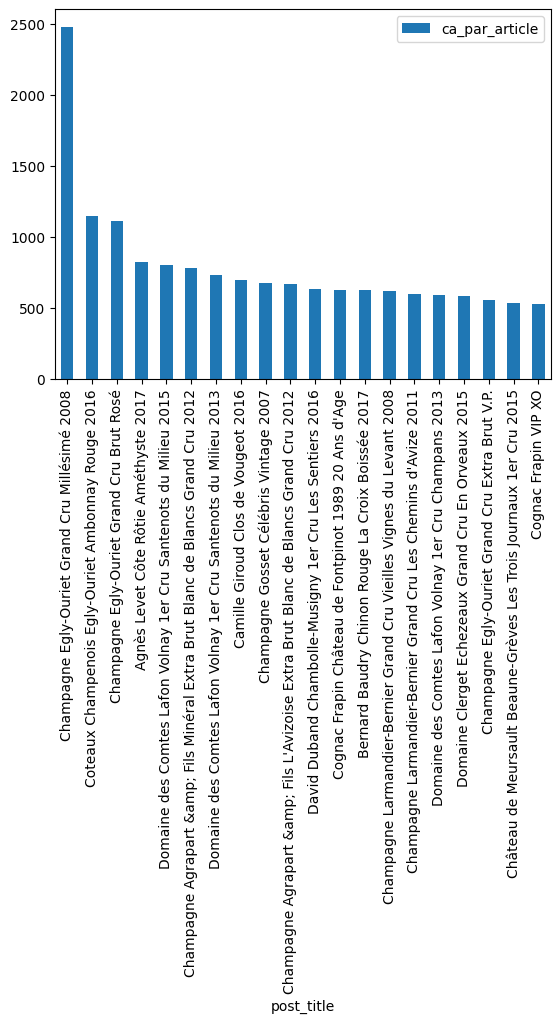

In [ ]:
top20.plot.bar('post_title','ca_par_article')

In [492]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge['part_CA']=df_merge['ca_par_article']/somme
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge['cumul_part_CA'] = df_merge['part_CA'].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA : 435
print(len(df_merge[df_merge['cumul_part_CA']<=0.8]))
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
len(df_merge[df_merge['cumul_part_CA']<=0.8])/len(df_merge)


435


0.5894308943089431

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

<Axes: xlabel='sku'>

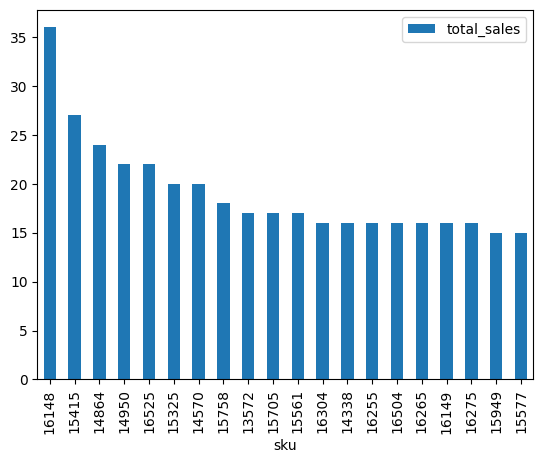

In [493]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge = df_merge.sort_values(by='total_sales',ascending=False).reset_index()
#Réinitialiser l'index du dataset par un reset_index

#Afficher les 20 premiers articles en quantité
top20a = df_merge.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
top20a.plot.bar(x='sku',y='total_sales')

In [494]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
sommeq = df_merge['total_sales'].sum(skipna=True)
df_merge['part_quantité'] = df_merge['total_sales']/sommeq
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge['cumul_part_quantité'] = df_merge['part_quantité'].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
print(len(df_merge[df_merge['cumul_part_quantité']<=0.8]))
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
len(df_merge[df_merge['cumul_part_quantité']<=0.8])/len(df_merge)

425


0.575880758807588

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [495]:
import numpy as np

<Axes: xlabel='sku'>

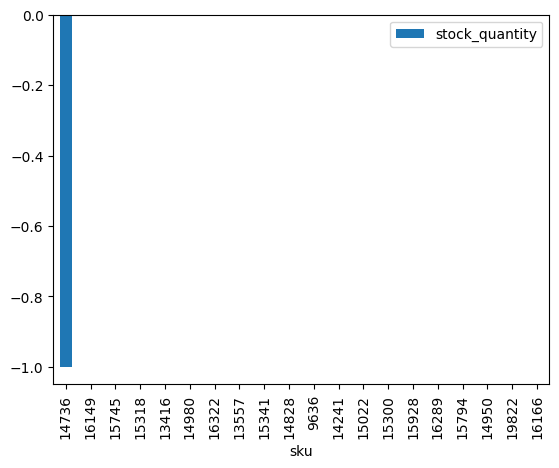

In [496]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
df_merge = df_merge.sort_values(by='stock_quantity',ascending=True).reset_index()
#Création de la colonne Rotation de stock

#Remplacement des "inf" par 0
flop20s = df_merge.head(20)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop20s.plot.bar(x='sku',y='stock_quantity')

In [511]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge['valorisation_stock_euros']=df_merge['price']*df_merge['stock_quantity']
#Calculer la somme de la colonne "Valorisation_stock_euros"
somme_valorisation = df_merge['valorisation_stock_euros'].sum()
somme_valorisation

np.float64(495687.0)

In [498]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
sommeq

np.float64(5687.0)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [499]:
df_merge

,level_0,index,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,...,product_type,post_title,_merge,z_score,ca_par_article,part_CA,cumul_part_CA,part_quantité,cumul_part_quantité,valorisation_stock_euros
0,383,61,5700.0,1.0,44.5,-1.0,outofstock,22.30,14736,14736,...,Vin,"Gilles Robin Crozes-Hermitage Rouge ""1920"" 2016",both,0.453991,356.0,0.002470,0.229750,0.001407,0.747846,-44.5
1,16,426,4870.0,1.0,9.3,0.0,outofstock,4.81,16149,16149,...,Vin,Triennes IGP Méditerranée Rosé 2019,both,-0.835727,148.8,0.001032,0.791230,0.002813,0.059082,0.0
2,705,695,6301.0,1.0,40.5,0.0,outofstock,20.51,15745,15745,...,Vin,Borie La Vitarèle Saint-Chinian Midi Rouge 2015,both,0.307433,0.0,0.000000,1.000000,0.000000,1.012836,0.0
3,704,694,6038.0,1.0,48.5,0.0,outofstock,25.31,15318,15318,...,Vin,I Fabbri Chianti Classico Gran Selezione 2015,both,0.600550,0.0,0.000000,1.000000,0.000000,1.012836,0.0
4,692,707,4100.0,1.0,15.8,0.0,outofstock,8.57,13416,13416,...,Vin,Emile Boeckel Gewurztraminer Grand Cru Zotzenb...,both,-0.597568,0.0,0.000000,1.000000,0.000000,1.012836,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,424,74,4334.0,1.0,49.0,142.0,instock,30.01,7818,7818,...,Champagne,Champagne Gosset Grand Blanc de Blancs,both,0.618870,343.0,0.002380,0.261186,0.001231,0.799015,6958.0
734,702,692,4337.0,1.0,83.0,145.0,instock,48.90,4679,4679,...,Champagne,Champagne Mailly Grand Cru Les Echansons 2007,both,1.864621,0.0,0.000000,1.000000,0.000000,1.012836,12035.0
735,393,17,4350.0,1.0,79.5,145.0,instock,47.30,12588,12588,...,Champagne,Champagne Egly-Ouriet Grand Cru Extra Brut V.P.,both,1.736382,556.5,0.003861,0.102436,0.001231,0.760858,11527.5
736,716,737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,right_only,NaN,NaN,NaN,NaN,-0.002989,1.009847,NaN


In [500]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT

#Création de la colonne Taux de marge
df_merge['taux_marge'] = df_merge['purchase_price']/df_merge['price']
#Afficher le prix minimum de la colonne "taux_marge"
print(f"{min(df_merge['taux_marge'])*100}%")
#Afficher le prix maximum de la colonne "taux_marge"
print(f"{max(df_merge['taux_marge'])*100}%")

43.536%
612.4901185770751%


In [501]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_merge[df_merge['taux_marge']<0]

,level_0,index,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,...,post_title,_merge,z_score,ca_par_article,part_CA,cumul_part_CA,part_quantité,cumul_part_quantité,valorisation_stock_euros,taux_marge


In [502]:
#Création d'un dataframe avec les taux positifs
df_marge = df_merge[df_merge['taux_marge']>0]
#Afficher le prix minimum de la colonne "taux_marge"
print(f"{min(df_marge['taux_marge'])*100}%")
#Afficher le prix maximum de la colonne "taux_marge"
print(f"{max(df_marge['taux_marge'])*100}%")

43.536%
612.4901185770751%


<Axes: ylabel='taux_marge'>

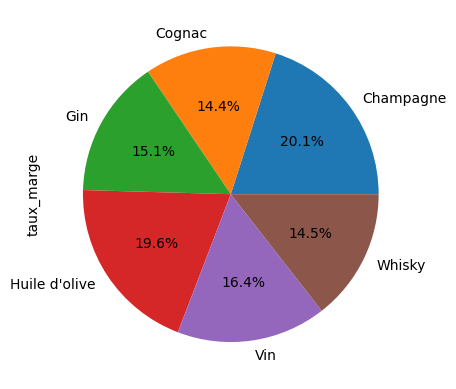

In [503]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_taux_moyen = df_marge.groupby('product_type',as_index=False).agg({'purchase_price':'sum','price':'sum'})
df_taux_moyen['taux_marge']=df_taux_moyen['purchase_price']/df_taux_moyen['price']
#Affichage dans un graphique du taux de marge par type de produit
df_taux_moyen.set_index("product_type")['taux_marge'].plot.pie(autopct='%1.1f%%')

In [504]:
df_taux_moyen

,product_type,purchase_price,price,taux_marge
0,Champagne,1236.60,1949.55,0.634300
1,Cognac,354.29,780.00,0.454218
2,Gin,34.32,72.00,0.476667
3,Huile d'olive,46.35,74.80,0.619652
4,Vin,10014.86,19366.20,0.517131
5,Whisky,419.12,917.80,0.456657


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

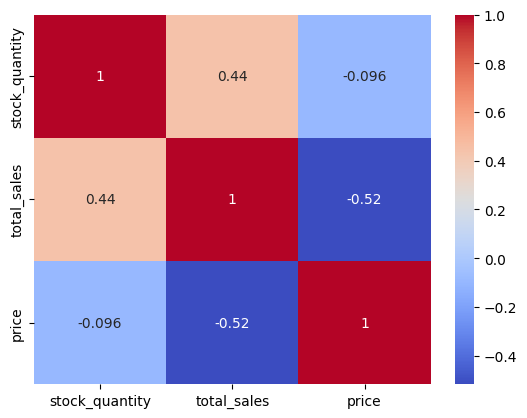

In [505]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
#Création d'une heatmap de corrélation avec les variables stock, sales et price
sns.heatmap(df_merge[['stock_quantity','total_sales','price']].corr(),annot=True,cmap="coolwarm")
#On peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(df_merge[['stock_quantity','total_sales','price']].corr(),dtype=bool))

<Axes: >

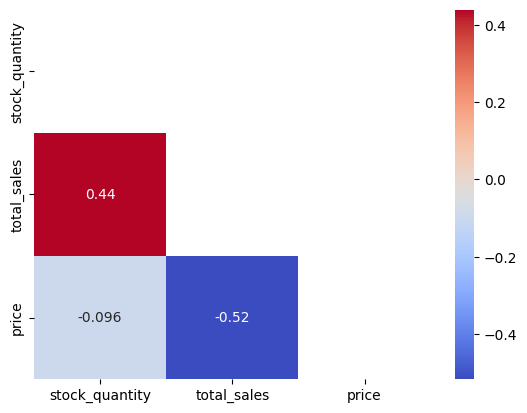

In [506]:
sns.heatmap(df_merge[['stock_quantity','total_sales','price']].corr(),mask=mask,annot=True,cmap='coolwarm')

In [507]:
#Que peut-on conclure des corrélations ?
# plus on vend plus il faut de stock, plus c'est cher moins on vend, le prix et le stock ne sont pas liés

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [508]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_merge.to_excel("df_merge.xlsx")